# Disease Prediction from Symptoms (XGBoost + SMOTE)

This notebook trains a machine learning model that predicts the most likely diseases from a set of symptoms.
The dataset is a symptom → prognosis table where each symptom is a binary feature (0/1).

Main ideas used here:
- **SMOTE** to handle class imbalance (rare diseases)
- **XGBoost** because it works well for multi-class classification problems
- A simple **interactive widget** to try predictions by selecting symptoms

> ⚠️ Disclaimer: This is an educational ML project. It is **not medical advice**.


In [1]:
!pip -q install pandas numpy scikit-learn imbalanced-learn xgboost ipywidgets joblib matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import joblib
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display


In [3]:
# Dataset hosted on Google Drive (public file)
file_id = "1e7v5112Y6xSMJZCQiYsxq1lckGMraW0z"
file_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(file_url)
df.head()


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [4]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Unique diseases:", df["prognosis"].nunique())
print("Example diseases:", df["prognosis"].unique()[:8])


Dataset shape: (4920, 133)
Missing values: 0
Unique diseases: 41
Example diseases: ['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ']


## Feature/Target split

- `X` = all symptom columns (binary features)
- `y` = prognosis (disease label)

Since `y` is text labels, we encode it using `LabelEncoder` so the classifier can learn.


In [5]:
X = df.drop(columns=["prognosis"])
y = df["prognosis"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

# stratify keeps class distribution similar in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

feature_names = X.columns.tolist()

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (3936, 132)  Test: (984, 132)


## Model training (SMOTE + XGBoost)

Medical-style datasets often have imbalance (some diseases occur far less than others).
To reduce bias toward frequent diseases, we use **SMOTE** only on the training set.

Then we train an **XGBoost** classifier in multi-class probability mode.


In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Balanced train:", X_train_bal.shape)


Balanced train: (3936, 132)


In [7]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=1,
    reg_lambda=2,

    objective="multi:softprob",
    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1
)
model.fit(X_train_bal, y_train_bal)

print("Train accuracy:", model.score(X_train_bal, y_train_bal))
print("Test accuracy :", model.score(X_test, y_test))


Train accuracy: 1.0
Test accuracy : 1.0


> Note: Very high accuracy here likely reflects the clean and separable nature of this dataset.  
> Real-world medical data is noisier and would require external validation.


In [8]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix shape:", cm.shape)


Accuracy: 1.0

Classification report:

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.0

In [9]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=2,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, y_enc, cv=cv, scoring="accuracy")

print("CV scores:", scores)
print("Mean CV:", scores.mean())
print("Std CV:", scores.std())


CV scores: [1. 1. 1. 1. 1.]
Mean CV: 1.0
Std CV: 0.0


In [10]:
# Simple CV on training data (without SMOTE inside the CV loop).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring="accuracy")
print("CV scores:", cv_scores)
print("Mean CV:", cv_scores.mean())
print("Std CV :", cv_scores.std())


CV scores: [1. 1. 1. 1. 1.]
Mean CV: 1.0
Std CV : 0.0


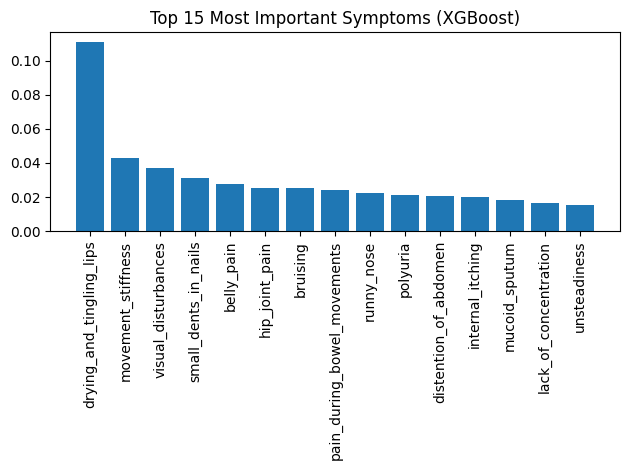

In [11]:
importances = model.feature_importances_
top_idx = np.argsort(importances)[-15:][::-1]

plt.figure()
plt.bar(range(len(top_idx)), importances[top_idx])
plt.xticks(range(len(top_idx)), [feature_names[i] for i in top_idx], rotation=90)
plt.title("Top 15 Most Important Symptoms (XGBoost)")
plt.tight_layout()
plt.show()


## Saving the model

To avoid the common mistake of feature-order mismatch later, we save:
- the trained model
- the label encoder (disease name mapping)
- the feature list (`X.columns`) used during training

All of it is saved as one bundle file.

In [12]:
bundle = {
    "model": model,
    "label_encoder": le,
    "feature_names": feature_names
}

joblib.dump(bundle, "disease_predictor_bundle.pkl")
print("Saved: disease_predictor_bundle.pkl")


Saved: disease_predictor_bundle.pkl


In [13]:
from typing import List, Tuple, Dict, Any

def predict_top_diseases(symptoms: List[str], bundle: Dict[str, Any], top_n: int = 3) -> List[Tuple[str, float]]:
    """
    Predict top-N diseases based on selected symptoms.

    symptoms: list of symptom names (strings that match training columns)
    bundle: dict with model, label_encoder, feature_names
    top_n: how many predictions to return

    returns: list of (disease_name, probability) sorted high → low
    """
    model = bundle["model"]
    label_encoder = bundle["label_encoder"]
    feature_names = bundle["feature_names"]

    # Clean input a bit
    symptoms = [s.strip() for s in symptoms if isinstance(s, str) and s.strip()]
    if not symptoms:
        return []

    feature_index = {name: i for i, name in enumerate(feature_names)}
    x = np.zeros(len(feature_names), dtype=np.int32)

    # Mark selected symptoms as present (1)
    for s in symptoms:
        if s in feature_index:
            x[feature_index[s]] = 1

    probas = model.predict_proba(x.reshape(1, -1))[0]

    top_n = max(1, min(int(top_n), len(probas)))
    top_idx = np.argsort(probas)[-top_n:][::-1]

    diseases = label_encoder.inverse_transform(top_idx)
    results = [(diseases[i], float(probas[top_idx[i]])) for i in range(top_n)]

    return results


## Interactive prediction widget

Use the symptom list to select what you’re experiencing.
- Select **at least 3 symptoms** (less than that is too vague)
- Click **Predict Disease**
- You’ll get the top 3 predictions + probabilities


In [14]:
bundle = joblib.load("disease_predictor_bundle.pkl")
all_symptoms = bundle["feature_names"]

multi_select = widgets.SelectMultiple(
    options=all_symptoms,
    description="Symptoms",
    layout=widgets.Layout(width="70%", height="240px")
)

button = widgets.Button(description="Predict Disease", button_style="success")
output = widgets.Output()

def on_button_clicked(_):
    output.clear_output()
    with output:
        selected = list(multi_select.value)

        if len(selected) < 3:
            print("Pick at least 3 symptoms for a more meaningful prediction.")
            return

        preds = predict_top_diseases(selected, bundle, top_n=3)

        print("Top predictions (educational only):\n")
        for i, (disease, prob) in enumerate(preds, 1):
            print(f"{i}. {disease} — {prob*100:.1f}%")

button.on_click(on_button_clicked)

display(multi_select, button, output)


SelectMultiple(description='Symptoms', layout=Layout(height='240px', width='70%'), options=('itching', 'skin_r…

Button(button_style='success', description='Predict Disease', style=ButtonStyle())

Output()

In [15]:
requirements = """pandas
numpy
scikit-learn
imbalanced-learn
xgboost
ipywidgets
joblib
matplotlib
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("Wrote requirements.txt")


Wrote requirements.txt


In [16]:
pip install -r requirements.txt
